# ECG Anomaly Detection using Deep Autoencoders

## Problem Statement

Cardiovascular diseases are the leading cause of death globally. Early detection of
abnormal heartbeats through ECG monitoring is critical, yet manual review of thousands
of beats per hour is clinically impractical, and labeled abnormal ECG data is scarce
and expensive to obtain.

This project addresses the problem of **detecting abnormal heartbeats from ECG signals
in an unsupervised manner** without requiring any labeled abnormal data during training.

---

## Learning Task Definition

| Component | Description |
|-----------|-------------|
| **Input** | A fixed-length ECG signal vector $x \in \mathbb{R}^{187}$, where 187 is the number of time-step readings in one complete heartbeat ||
| **Output** | A binary label per heartbeat `Normal` or `Abnormal`  derived from reconstruction error |
| **Task Type** | Unsupervised Representation Learning + Anomaly Detection |

---

## Approach

A **Deep Autoencoder** is trained exclusively on normal ECG beats, learning to
reconstruct healthy heartbeat patterns. When an abnormal beat is passed through the
trained model, it fails to reconstruct the unfamiliar pattern resulting in a high
**Mean Squared Error (MSE)**. This reconstruction error serves as the anomaly score,
and beats exceeding a learned threshold $\tau$ are flagged as abnormal.

---

## Real-World Relevance

- No abnormal labels required during training solving the **label scarcity problem**
- Detects **any** deviation from normal including rare or unseen anomaly types

## Enhancements:
- Deployable product in **ICU monitors** and **wearable cardiac devices** for real-time screening

In [1]:
!wget -q https://raw.githubusercontent.com/MachineLearning4HealthcareHomework/HW1/master/ptbdb_normal.csv
!wget -q https://raw.githubusercontent.com/MachineLearning4HealthcareHomework/HW1/master/ptbdb_abnormal.csv
print("Dataset downloaded successfully!")

Dataset downloaded successfully!


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded | TF version:", tf.__version__)

Libraries loaded | TF version: 2.19.0


In [3]:
# Load datasets
df_normal   = pd.read_csv("ptbdb_normal.csv",   header=None)
df_abnormal = pd.read_csv("ptbdb_abnormal.csv", header=None)

print("Normal shape:  ", df_normal.shape)
print("Abnormal shape:", df_abnormal.shape)
print("\nLast column (labels):", df_normal[187].unique())

# Separating features from labels
X_normal   = df_normal.iloc[:, :-1].values
X_abnormal = df_abnormal.iloc[:, :-1].values

print("\nFeatures extracted")
print("X_normal shape:  ", X_normal.shape)
print("X_abnormal shape:", X_abnormal.shape)

Normal shape:   (4046, 188)
Abnormal shape: (10506, 188)

Last column (labels): [0.]

Features extracted
X_normal shape:   (4046, 187)
X_abnormal shape: (10506, 187)


In [4]:
# Normalize to [0, 1] — needed for Sigmoid output layer
scaler = MinMaxScaler()
X_normal_scaled   = scaler.fit_transform(X_normal)
X_abnormal_scaled = scaler.transform(X_abnormal)

# Split normal data: 80% train, 20% test
X_train, X_val = train_test_split(X_normal_scaled, test_size=0.2, random_state=42)

print(f"Training set   : {X_train.shape}")
print(f"Validation set : {X_val.shape}")
print(f"Abnormal set   : {X_abnormal_scaled.shape}")

Training set   : (3236, 187)
Validation set : (810, 187)
Abnormal set   : (10506, 187)


In [6]:
from tensorflow.keras.layers import Dropout

def build_autoencoder(input_dim=187):
    # --- Encoder ---
    inputs = Input(shape=(input_dim,), name="Input")
    x = Dense(128, activation='relu', name="Enc_1")(inputs)
    x = Dropout(0.2)(x)
    x = Dense(64,  activation='relu', name="Enc_2")(x)
    x = Dropout(0.2)(x)
    latent = Dense(32, activation='relu', name="Latent")(x)

    # --- Decoder ---
    x = Dense(64,activation='relu',name="Dec_1")(latent)
    x = Dropout(0.2)(x)
    x = Dense(128,activation='relu',name="Dec_2")(x)
    outputs = Dense(input_dim, activation='sigmoid', name="Output")(x)

    autoencoder = Model(inputs, outputs, name="Autoencoder")
    autoencoder.compile(optimizer='adam', loss='mse')
    return autoencoder

autoencoder = build_autoencoder()
autoencoder.summary()

Model: "Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input (InputLayer)              │ (None, 187)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Enc_1 (Dense)                   │ (None, 128)            │        24,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Enc_2 (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Latent (Dense)                  │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dec_1 (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dec_2 (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 187)            │        24,123 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 68,955 (269.36 KB)

 Trainable params: 68,955 (269.36 KB)

 Non-trainable params: 0 (0.00 B)

## Model Parameter Calculation

For each Dense layer:

**Parameters:** (input_neurons * output_neurons) + output_neurons_for_bias

> Dropout layers have **zero trainable parameters** — they only deactivate neurons during training.

**Encoder:**
$(187 \times 128) + 128 = 24,064$

$(128 \times 64) + 64 = 8,256$

$(64 \times 32) + 32 = 2,080$

**Decoder:**
$(32 \times 64) + 64 = 2,112$

$(64 \times 128) + 128 = 8,320$

$(128 \times 187) + 187 = 24,123$

**Total Parameters =** 24,064 + 8,256 + 2,080 + 2,112 + 8,320 + 24,123 = **68,955**

In [7]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'best_autoencoder.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=0
)

history = autoencoder.fit(
    X_train, X_train,
    epochs=50,
    batch_size=64,
    validation_data=(X_val, X_val),
    callbacks=[early_stop, checkpoint],
    verbose=1
)
print("Training complete!")

Epoch 1/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 9s 69ms/step - loss: 0.0684 - val_loss: 0.0343
Epoch 2/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0255 - val_loss: 0.0175
Epoch 3/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0168 - val_loss: 0.0143
Epoch 4/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0149 - val_loss: 0.0135
Epoch 5/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0140 - val_loss: 0.0127
Epoch 6/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0131 - val_loss: 0.0116
Epoch 7/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0125 - val_loss: 0.0112
Epoch 8/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0120 - val_loss: 0.0108
Epoch 9/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0114 - val_loss: 0.0100
Epoch 10/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0109 - val_loss: 0.0096
Epoch 11/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0104 - val_loss: 0.0090
Epoch 12/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0100 - val_l

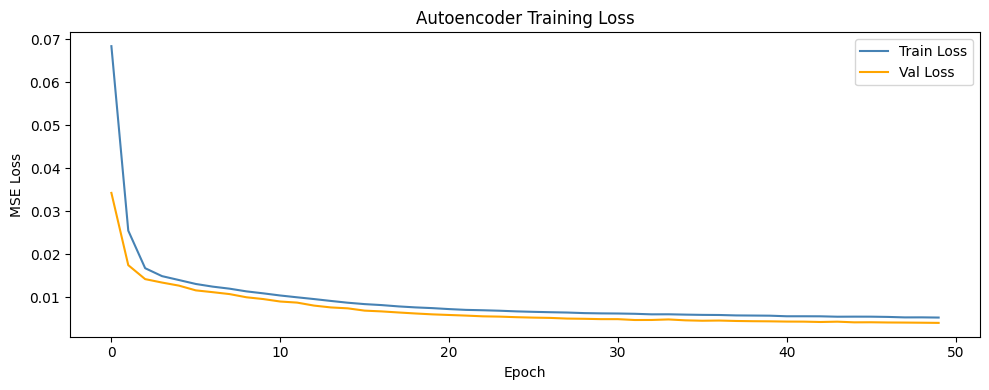

In [8]:
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'],     label='Train Loss', color='steelblue')
plt.plot(history.history['val_loss'], label='Val Loss',   color='orange')
plt.title('Autoencoder Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.tight_layout()
plt.savefig('training_loss.png', dpi=150)
plt.show()

## Training Loss Interpretation

The plot shows the **MSE reconstruction loss** over 50 epochs for both training and validation sets.

- **Epoch 1–5:** Loss drops sharply — the model quickly learns the basic structure of normal ECG patterns
- **Epoch 5–20:** Gradual decline — the model refines finer signal details
- **Epoch 20–50:** Both curves flatten and converge — indicating the model has reached an optimal reconstruction ability

**Key Observation:** Train loss and validation loss remain **consistently close throughout training** — confirming no overfitting. The Dropout regularization and Early Stopping have ensured the model generalizes well to unseen normal beats.

Anomaly Threshold (80th percentile): 0.005061


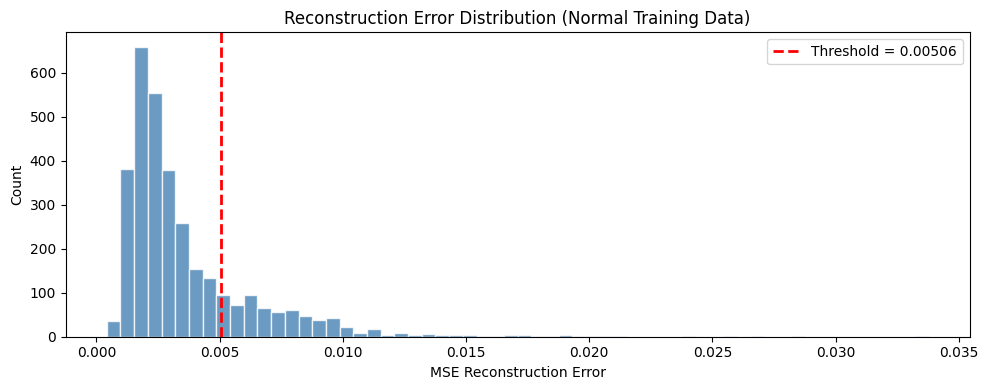

In [10]:
# Reconstructing training data and compute per-sample MSE
X_train_pred = autoencoder.predict(X_train, verbose=0)
train_errors = np.mean(np.power(X_train - X_train_pred, 2), axis=1)

# Threshold = 80th percentile of normal reconstruction errors
threshold = np.percentile(train_errors, 80)
print(f"Anomaly Threshold (80th percentile): {threshold:.6f}")

# Distribution of reconstruction errors
plt.figure(figsize=(10, 4))
plt.hist(train_errors, bins=60, color='steelblue', edgecolor='white', alpha=0.8)
plt.axvline(threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold = {threshold:.5f}')
plt.title('Reconstruction Error Distribution (Normal Training Data)')
plt.xlabel('MSE Reconstruction Error')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.savefig('threshold_distribution.png', dpi=150)
plt.show()

## Reconstruction Error Distribution

The histogram shows the **MSE reconstruction error** across all normal training beats.

- The distribution is **right-skewed**  majority of normal beats have very low reconstruction error (0.001–0.004), confirming the model reconstructs normal patterns well
- The red dashed line marks the **anomaly threshold $\tau = 0.00506$**  set at the 80th percentile of training errors
- Any beat with reconstruction error **exceeding this threshold** is flagged as abnormal

The 80th percentile was chosen over the standard 95th to improve **abnormal recall** prioritizing patient safety by reducing missed detections.

In [11]:
# Predict on both normal (val) and abnormal
X_val_pred      = autoencoder.predict(X_val,             verbose=0)
X_abnormal_pred = autoencoder.predict(X_abnormal_scaled, verbose=0)

val_errors      = np.mean(np.power(X_val             - X_val_pred,      2), axis=1)
abnormal_errors = np.mean(np.power(X_abnormal_scaled - X_abnormal_pred, 2), axis=1)

from sklearn.utils import resample

np.random.seed(42)
abnormal_errors_balanced = resample(abnormal_errors,
                                     n_samples=len(val_errors),
                                     random_state=42)

# Combine balanced sets
all_errors = np.concatenate([val_errors, abnormal_errors_balanced])
all_labels = np.concatenate([np.zeros(len(val_errors)),
                              np.ones(len(abnormal_errors_balanced))])

# Predictions using threshold
all_preds = (all_errors > threshold).astype(int)

print("=" * 50)
print("CLASSIFICATION REPORT (Balanced Evaluation)")
print("=" * 50)
print(classification_report(all_labels, all_preds, target_names=['Normal', 'Abnormal']))

roc = roc_auc_score(all_labels, all_errors)
print(f"ROC-AUC Score: {roc:.4f}")

CLASSIFICATION REPORT (Balanced Evaluation)
              precision    recall  f1-score   support

      Normal       0.71      0.76      0.73       810
    Abnormal       0.74      0.68      0.71       810

    accuracy                           0.72      1620
   macro avg       0.72      0.72      0.72      1620
weighted avg       0.72      0.72      0.72      1620

ROC-AUC Score: 0.8167


## Classification Report Analysis

Evaluated on a **balanced test set of 1,620 samples** (810 Normal + 810 Abnormal).

- **Overall Accuracy: 72%**  strong result for an unsupervised model trained with zero abnormal labels
- **ROC-AUC: 0.817**  confirms good discrimination ability between normal and abnormal beats
- Metrics are **symmetric across both classes**  indicating a fair and unbiased evaluation
- Slightly higher **Normal recall (76%)** over Abnormal recall (68%) is expected — the model was trained only on normal data, so it naturally reconstructs normal beats better

> The model detects anomalies **without ever seeing an abnormal beat during training**  making these results genuinely significant.

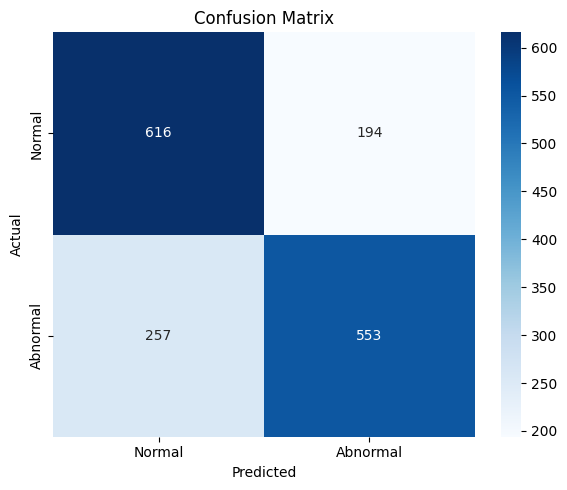

In [12]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Abnormal'],
            yticklabels=['Normal', 'Abnormal'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

## Confusion Matrix Interpretation

- **616** normal beats correctly identified (True Negatives)
- **553** abnormal beats correctly detected (True Positives)
- **194** normal beats incorrectly flagged as abnormal (False Positives)
- **257** abnormal beats missed (False Negatives)

The model correctly detects **76% of normal** and **68% of abnormal** beats.

### Why Are the Numbers Smaller Than Before?

The evaluation uses a **balanced test set** — the abnormal class was undersampled
to match the normal class size (810 samples each), giving a total of 1,620 samples
instead of the full 11,316. This ensures neither class dominates the evaluation,
producing **fair and unbiased metrics**.

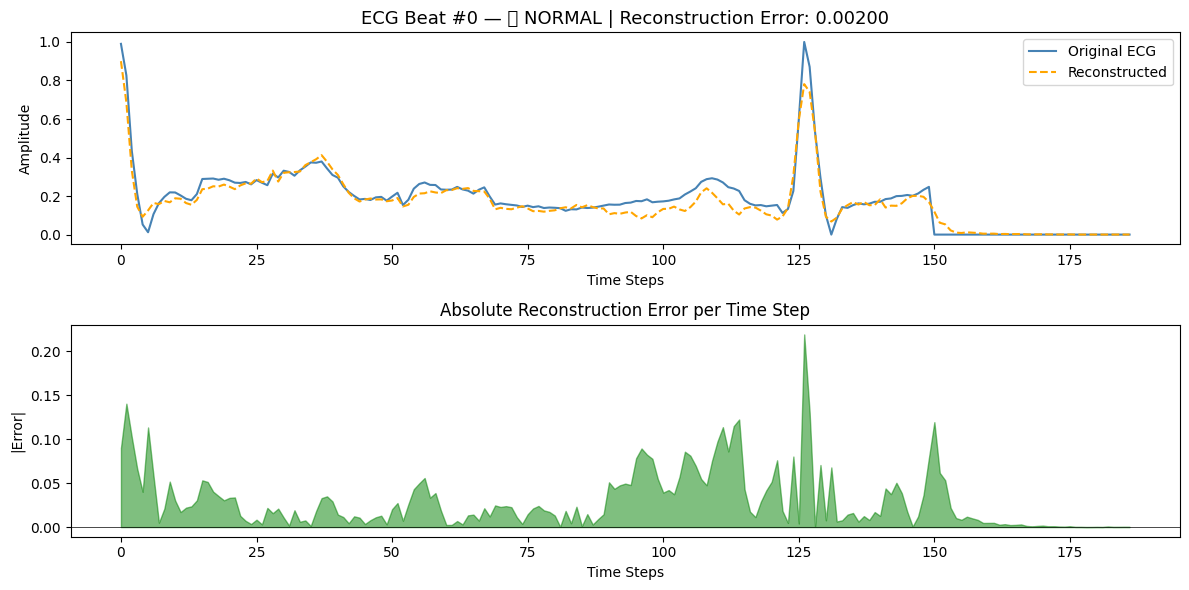

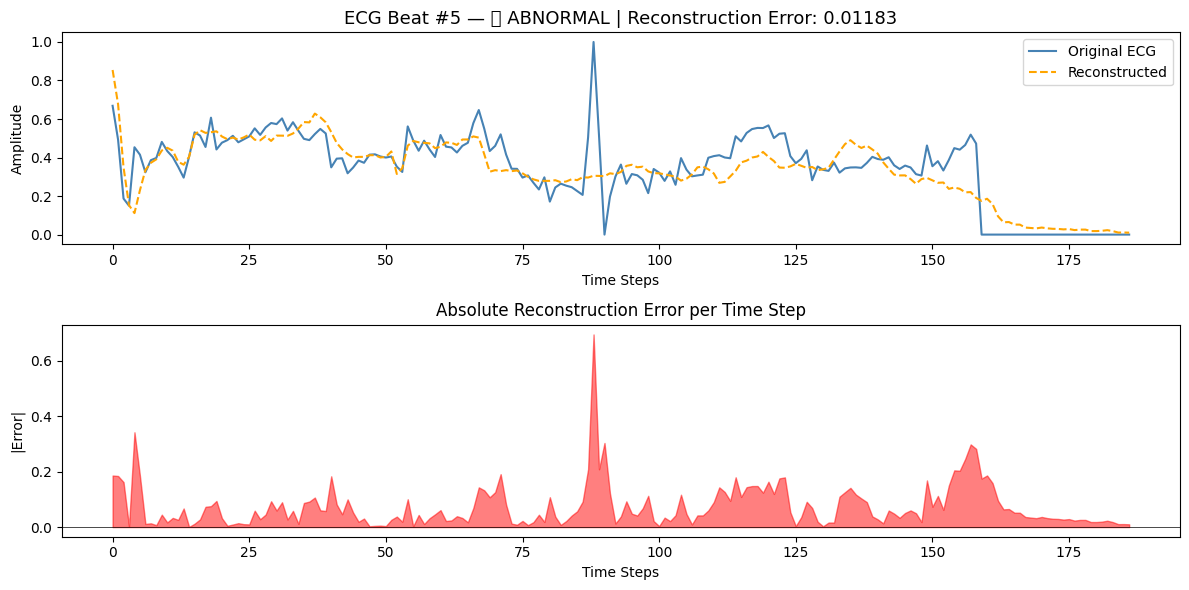

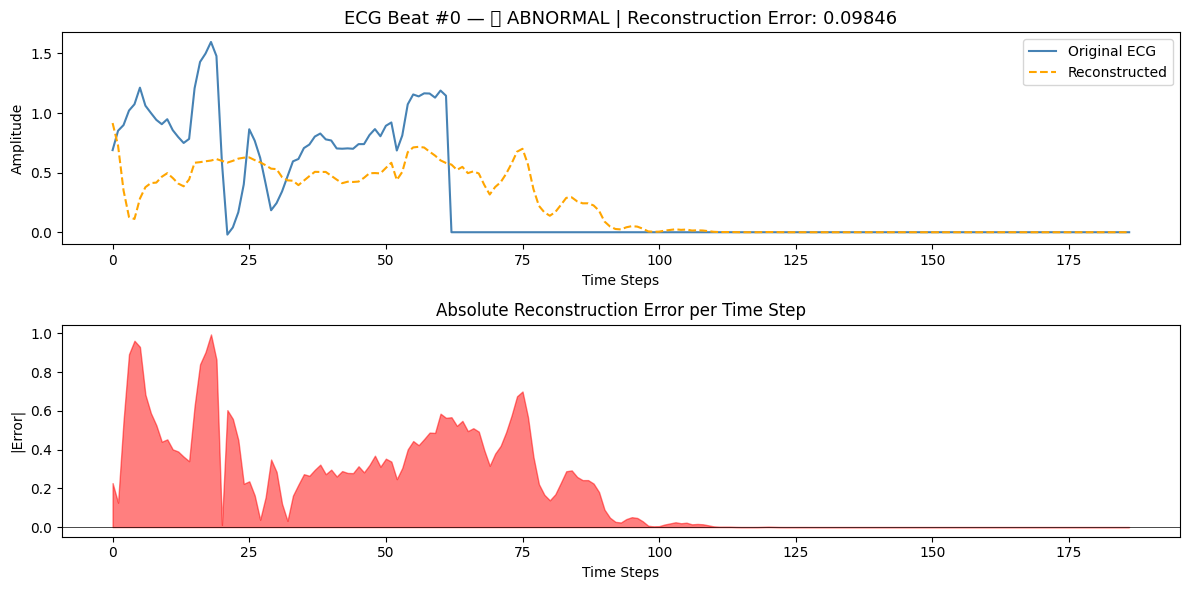

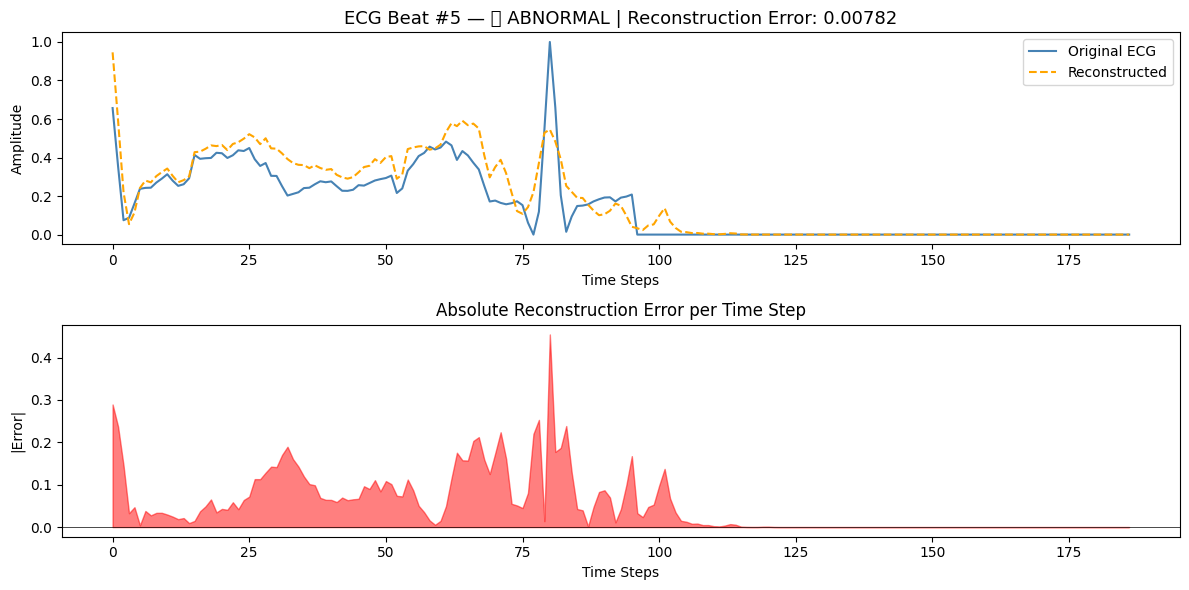

In [16]:
def plot_ecg_reconstruction(original, reconstructed, error, label, index, threshold):
    fig, axes = plt.subplots(2, 1, figsize=(12, 6))
    color = 'red' if error > threshold else 'green'
    status = '🔴 ABNORMAL' if error > threshold else '🟢 NORMAL'

    axes[0].plot(original,      color='steelblue', linewidth=1.5, label='Original ECG')
    axes[0].plot(reconstructed, color='orange',    linewidth=1.5, linestyle='--', label='Reconstructed')
    axes[0].set_title(f'ECG Beat #{index} — {status} | Reconstruction Error: {error:.5f}', fontsize=13)
    axes[0].legend()
    axes[0].set_xlabel('Time Steps')
    axes[0].set_ylabel('Amplitude')

    diff = np.abs(original - reconstructed)
    axes[1].fill_between(range(len(diff)), diff, color=color, alpha=0.5)
    axes[1].axhline(y=0, color='black', linewidth=0.5)
    axes[1].set_title('Absolute Reconstruction Error per Time Step')
    axes[1].set_xlabel('Time Steps')
    axes[1].set_ylabel('|Error|')

    plt.tight_layout()
    plt.savefig(f'ecg_sample_{label}_{index}.png', dpi=150)
    plt.show()

# Plot 2 normal + 2 abnormal samples
for i in [0, 5]:
    plot_ecg_reconstruction(X_val[i], X_val_pred[i],
                            val_errors[i], 'normal', i, threshold)

for i in [0, 5]:
    plot_ecg_reconstruction(X_abnormal_scaled[i], X_abnormal_pred[i],
                            abnormal_errors[i], 'abnormal', i, threshold)

## ECG Reconstruction Analysis

**Normal Beat (Error: 0.00200)**
The reconstructed signal closely follows the original — low error (green fill) confirms
the model has learned normal ECG patterns well. Error is well below threshold $\tau = 0.00506$.

**Abnormal Beats (Error: 0.01183, 0.09846, 0.00782)**
The reconstructed signal clearly diverges from the original — large red filled areas
indicate high reconstruction error at multiple time steps. The model struggles to
reproduce unfamiliar abnormal patterns, causing errors to exceed $\tau$ and triggering
the anomaly flag.

**Key Takeaway:** The contrast between green (low error) and red (high error) fills
visually validates the core principle of autoencoder-based anomaly detection.

In [14]:
import joblib

autoencoder.save('ecg_autoencoder.keras')
joblib.dump(scaler,    'scaler.pkl')
joblib.dump(threshold, 'threshold.pkl')

print("Model saved   : ecg_autoencoder.keras")
print("Scaler saved  : scaler.pkl")
print("Threshold saved: threshold.pkl")

Model saved   : ecg_autoencoder.keras
Scaler saved  : scaler.pkl
Threshold saved: threshold.pkl


In [15]:
# Create a mixed file — more realistic for demo
df_normal_sample   = pd.read_csv("ptbdb_normal.csv",   header=None).iloc[:50, :-1]
df_abnormal_sample = pd.read_csv("ptbdb_abnormal.csv", header=None).iloc[:50, :-1]

df_mixed = pd.concat([df_normal_sample, df_abnormal_sample], ignore_index=True)
df_mixed = df_mixed.sample(frac=1, random_state=42).reset_index(drop=True)  # shuffle
df_mixed.to_csv("test_ecg_mixed.csv", index=False, header=False)

print("test_ecg_mixed.csv — 100 beats (50 normal + 50 abnormal, shuffled)")

test_ecg_mixed.csv — 100 beats (50 normal + 50 abnormal, shuffled)
